 Import necessary libraries

In [1]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("NAME: AKHIL C\nROLL NO: 24BAD007")

NAME: AKHIL C
ROLL NO: 24BAD007


**Load Dataset**

In [2]:
# Load the MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


**Preprocess Dataset**

In [3]:
# Preprocess the dataset

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 784)
Testing Images: (10000, 784)
Training Labels: (60000, 10)
Testing Labels: (10000, 10)


**Build ANN Model**

In [4]:
# Build and compile ANN model

def build_model(activation):

    model = Sequential([
        Dense(128, activation=activation, input_shape=(784,)),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


activation_functions = ["relu", "sigmoid", "tanh"]

history_dict = {}
evaluation_dict = {}

**Train Models**

In [5]:
# Train and evaluate models

for activation in activation_functions:

    print("-" * 50)
    print(f"Training Model with {activation.upper()} Activation")
    print("-" * 50)

    model = build_model(activation)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    history_dict[activation] = history

    evaluation_dict[activation] = {
        "loss": loss,
        "accuracy": accuracy
    }

    print(f"\nFinal Test Loss     : {loss:.4f}")
    print(f"Final Test Accuracy : {accuracy:.4f}\n")

--------------------------------------------------
Training Model with RELU Activation
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9303 - loss: 0.2365 - val_accuracy: 0.9573 - val_loss: 0.1330
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9704 - loss: 0.0985 - val_accuracy: 0.9676 - val_loss: 0.1087
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9784 - loss: 0.0705 - val_accuracy: 0.9723 - val_loss: 0.0912
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9825 - loss: 0.0532 - val_accuracy: 0.9765 - val_loss: 0.0793
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9858 - loss: 0.0425 - val_accuracy: 0.9739 - val_loss: 0.0861
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9890 - loss: 0.0338 - val_accuracy: 0.9757 - val_loss: 0.0831
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9903 - loss: 0.0288 - val_accuracy: 0.9772 - val_loss: 0.0794
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9929 - loss: 0.0226 - 

**Comparison Table**

In [6]:
# Activation Function Comparison

print("\nActivation Function Comparison")
print("-" * 50)

for activation in activation_functions:

    print(
        f"{activation.upper():10} "
        f"Accuracy: {evaluation_dict[activation]['accuracy']:.4f} | "
        f"Loss: {evaluation_dict[activation]['loss']:.4f}"
    )


Activation Function Comparison
--------------------------------------------------
RELU       Accuracy: 0.9777 | Loss: 0.0931
SIGMOID    Accuracy: 0.9765 | Loss: 0.0804
TANH       Accuracy: 0.9775 | Loss: 0.0935


**Training & Validation Accuracy Graph**

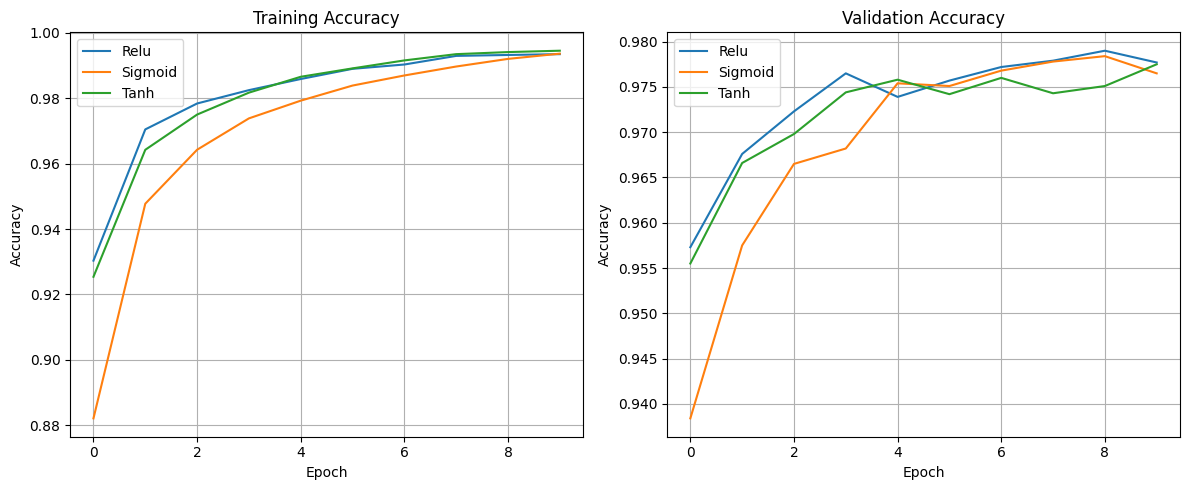

In [7]:
# Plot Accuracy Graph

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['accuracy'],
        label=activation.capitalize()
    )

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['val_accuracy'],
        label=activation.capitalize()
    )

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()